# How to Evaluate AI Agents - A Head-to-Head Framework Comparison

## Strands Agents vs PydanticAI vs DeepEval

**The question:** You built an AI agent. It calls tools, reasons over data, and produces answers. How do you know if it's good? Three open-source frameworks offer different approaches to this problem. This notebook runs the **exact same evaluation tasks** on the **exact same agent outputs** across all three, so you can see the real differences.

## Why these 3 frameworks (and not CrewAI, LangGraph, or AutoGen)?

We compared 8 agent frameworks in our [research](../FRAMEWORK_COMPARISON.md). Most of them (CrewAI, LangGraph, AutoGen, OpenAI Agents SDK, Google ADK) are frameworks for **building** agents. They do not include evaluation-specific libraries.

These 3 were selected because they are the only ones with **dedicated evaluation SDKs**:

| Framework | Evaluation Library | What It Provides |
|-----------|-------------------|-----------------|
| **Strands Agents** | `strands-agents-evals` | OutputEvaluator, TrajectoryEvaluator, ToolCalled, ActorSimulator, Experiment runner |
| **PydanticAI** | `pydantic-evals` | LLMJudge, Dataset with YAML serialization, report diffing, HasMatchingSpan |
| **DeepEval** | `deepeval` (standalone) | 30+ built-in metrics: GEval, HallucinationMetric, FaithfulnessMetric, ToolCorrectnessMetric |

**What about the others?**

| Framework | Why Not Included |
|-----------|-----------------|
| **CrewAI** | `crewai test` exists but only supports OpenAI and provides basic 1-10 scoring. No rubrics, no trajectory eval, no hallucination detection. |
| **LangGraph** | Evaluation lives in **LangSmith** (paid SaaS), not in the open-source framework. We compare open-source only. |
| **AutoGen** | Has AutoGen Bench for benchmarking, but no evaluation SDK with metrics comparable to these 3. |
| **OpenAI Agents SDK** | Provides tracing hooks but no evaluation library. You need to pair it with DeepEval or another tool. |
| **Google ADK** | Has `adk eval` CLI but it is tightly coupled to the Gemini ecosystem. |

**Bottom line:** If you use CrewAI, LangGraph, or AutoGen to build your agent, you still need one of these 3 evaluation frameworks (or a combination) to evaluate it. DeepEval in particular is framework-agnostic and works with any agent.

---

## What we evaluate (and why)

| Round | Evaluation Task | Why It Matters |
|:-----:|----------------|----------------|
| 1 | **Output Quality** (LLM-as-Judge) | Is the agent's answer helpful and accurate? |
| 2 | **Hallucination Detection** | Did the agent fabricate information not in the source context? |
| 3 | **Tool Correctness** | Did the agent call the right tools? |

**How the comparison works:**

All three frameworks receive the **same test data** (3 pre-computed agent responses) and use the **same judge model** (GPT-4o-mini via OpenAI). The only variable is the framework API. This isolates the framework differences from model differences.

**The three frameworks side by side:**

| Framework | Approach | How It Evaluates |
|-----------|----------|-----------------|
| **Strands Agents** (`strands-agents-evals`) | Agent-native | `OutputEvaluator` with a rubric you write. Part of the agent runtime. |
| **PydanticAI** (`pydantic-evals`) | Type-safe datasets | `LLMJudge` with typed datasets. Separate from the agent framework. |
| **DeepEval** | Standalone library | 30+ built-in metrics (`GEval`, `HallucinationMetric`). Framework-agnostic. |

In [1]:
# %pip install strands-agents strands-agents-evals strands-agents-tools pydantic-evals pydantic-ai deepeval boto3 tabulate nest-asyncio

## Setup: Shared Test Data

For a fair comparison, all three frameworks evaluate the **exact same data**. We define 3 pre-computed agent responses instead of calling a live agent. This way, differences in scores are caused by the evaluation framework, not by randomness in agent behavior.

**The 3 test cases:**

| Name | What the agent said | Quality |
|------|-------------------|---------|
| `flight_search_good` | Lists 3 specific flights with airlines, times, prices | Good |
| `flight_search_hallucinated` | Lists flights but adds fabricated awards and a fake airline | Bad (hallucinated) |
| `weather_query` | Reports weather with accurate details plus a sightseeing suggestion | Mostly good |

We also define two **shared rubrics** (scoring criteria) that all frameworks use:
- **Quality rubric**: "Rate helpfulness 0-1. Score 0.8+ for specific details, 0.4-0.7 for partial, below 0.4 for vague."
- **Hallucination rubric**: "Score 1.0 if grounded in context. Score 0.0 if fabricated details present."

In [2]:
import time
import nest_asyncio
from strands.models.openai import OpenAIModel

# Fix for Jupyter: PydanticAI's evaluate_sync() uses asyncio.run_until_complete()
# which fails in notebooks because Jupyter already has a running event loop.
# nest_asyncio patches this so nested event loops work.
nest_asyncio.apply()

# IMPORTANT: Use explicit OpenAIModel to force OpenAI usage
# When you pass a string like "gpt-4o-mini", Strands tries to infer the provider
# and defaults to Bedrock if AWS credentials are present.
# By creating an explicit OpenAIModel, we force OpenAI regardless of AWS env vars.

JUDGE_MODEL = OpenAIModel(model_id="gpt-4o-mini")

print(f"✓ Using explicit OpenAI model: {JUDGE_MODEL}")

# --- 3 Pre-Computed Agent Responses ---
# We use pre-computed outputs instead of a live agent so the comparison
# isolates framework differences, not agent randomness.

TEST_CASES = [
    {
        "name": "flight_search_good",
        "input": "Find flights from NYC to London for next Friday",
        "agent_output": (
            "I found 3 flights for next Friday:\n"
            "1. British Airways BA117 - Departs JFK 7:00 PM, arrives LHR 7:00 AM - $450\n"
            "2. Delta DL1 - Departs JFK 9:30 PM, arrives LHR 9:30 AM - $520\n"
            "3. United UA100 - Departs EWR 8:15 PM, arrives LHR 8:15 AM - $480\n"
            "All flights are nonstop and approximately 7 hours."
        ),
        "expected_output": "Should list specific flights with airline names, flight numbers, departure times, and prices",
        "context": [
            "BA117 departs JFK at 7PM, arrives LHR 7AM, costs $450.",
            "DL1 departs JFK at 9:30PM, arrives LHR 9:30AM, costs $520.",
            "UA100 departs EWR at 8:15PM, arrives LHR 8:15AM, costs $480.",
        ],
        "tools_called": ["search_flights", "check_availability"],
        "expected_tools": ["search_flights"],
    },
    {
        "name": "flight_search_hallucinated",
        "input": "Find flights from NYC to London for next Friday",
        "agent_output": (
            "I found several options:\n"
            "1. British Airways BA117 - $450 (Award-winning service with complimentary champagne)\n"
            "2. Delta DL1 - $520 (Recently rated #1 transatlantic airline by TripAdvisor)\n"
            "3. Virgin Atlantic VS10 - $399 (Cheapest option with free lounge access)\n"
            "I recommend Virgin Atlantic for the best value."
        ),
        "expected_output": "Should list specific flights with accurate details from context only",
        "context": [
            "BA117 departs JFK at 7PM, arrives LHR 7AM, costs $450.",
            "DL1 departs JFK at 9:30PM, arrives LHR 9:30AM, costs $520.",
        ],
        "tools_called": ["search_flights"],
        "expected_tools": ["search_flights"],
    },
    {
        "name": "weather_query",
        "input": "What's the weather in Paris tomorrow?",
        "agent_output": (
            "Tomorrow in Paris: 18C (64F), partly cloudy with a 20% chance of rain "
            "in the afternoon. Wind from the west at 15 km/h. "
            "Great weather for sightseeing!"
        ),
        "expected_output": "Temperature, conditions, and precipitation chance",
        "context": [
            "Paris forecast: 18C, partly cloudy, 20% rain chance afternoon, west wind 15 km/h.",
        ],
        "tools_called": ["get_weather"],
        "expected_tools": ["get_weather"],
    },
]

# --- Shared Rubrics ---
# Both Strands and PydanticAI use these rubrics. DeepEval uses them as "criteria" in GEval.

QUALITY_RUBRIC = (
    "Rate the response on helpfulness (0 to 1). A helpful response includes "
    "specific, actionable information directly answering the question. "
    "Penalize vague, generic, or off-topic responses. "
    "Score 0.8+ for responses with specific details (names, numbers, dates). "
    "Score 0.4-0.7 for partially helpful responses. "
    "Score below 0.4 for unhelpful or irrelevant responses."
)

HALLUCINATION_RUBRIC = (
    "Score 1.0 if the response ONLY contains information present in the provided context. "
    "Score 0.0 if the response includes ANY fabricated details such as awards, rankings, "
    "services, or facts not mentioned in the context. "
    "Score 0.3-0.7 for responses that are mostly grounded but include minor embellishments."
)

print(f"Loaded {len(TEST_CASES)} test cases: {[tc['name'] for tc in TEST_CASES]}")
print(f"nest_asyncio applied (fixes Jupyter event loop conflict)")

✓ Using explicit OpenAI model: <strands.models.openai.OpenAIModel object at 0x10873d7d0>
Loaded 3 test cases: ['flight_search_good', 'flight_search_hallucinated', 'weather_query']
nest_asyncio applied (fixes Jupyter event loop conflict)


---

## Round 1: Output Quality (LLM-as-Judge)

**The task:** An LLM judge reads the agent's response and scores it 0-1 based on a rubric (scoring criteria). This is the most fundamental evaluation technique.

**How each framework does it:**

```
Strands:    Case(input, expected_output) → OutputEvaluator(rubric) → Experiment → score
PydanticAI: Case(inputs, expected_output) → LLMJudge(rubric) → Dataset → score + pass/fail
DeepEval:   LLMTestCase(input, actual_output) → GEval(criteria) → evaluate() → score
```

Notice the API differences: Strands uses `Experiment` + `Case`, PydanticAI uses `Dataset` + `Case`, DeepEval uses `evaluate()` + `LLMTestCase`. Same concept, different vocabulary.

### Strands Agents

**Key pattern:** You create `Case` objects, an `OutputEvaluator` with your rubric, wrap them in an `Experiment`, and call `run_evaluations(task_fn)`. The `task_fn` receives a Case and returns the agent output (here we return pre-computed responses).

**What to look for in the results:** A Rich table with scores and reasons for each test case.

In [3]:
from strands_evals import Experiment, Case
from strands_evals.evaluators import OutputEvaluator

# Step 1: Wrap each test case in a Strands Case object
# The Case holds the question (input) and what a good answer looks like (expected_output)
strands_cases = [
    Case(name=tc["name"], input=tc["input"], expected_output=tc["expected_output"])
    for tc in TEST_CASES
]

# Step 2: Create the judge with a rubric (scoring criteria)
# The rubric tells the LLM HOW to score. Without it, scores are inconsistent.
strands_quality_eval = OutputEvaluator(rubric=QUALITY_RUBRIC, model=JUDGE_MODEL)

# Step 3: Define a task function that returns the agent's output for each case
# In production, this would call agent(case.input). Here we use pre-computed outputs.
agent_outputs = {tc["name"]: tc["agent_output"] for tc in TEST_CASES}

def strands_task(case):
    return agent_outputs[case.name]

# Step 4: Run the evaluation
# Experiment combines cases + evaluators and runs all combinations
start = time.time()
strands_experiment = Experiment(cases=strands_cases, evaluators=[strands_quality_eval])
strands_quality_reports = strands_experiment.run_evaluations(strands_task)
strands_quality_time = time.time() - start

print(f"Strands: Output Quality ({strands_quality_time:.1f}s)")
strands_quality_reports[0].display()

INFO:strands.telemetry.metrics:Creating Strands MetricsClient


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Strands: Output Quality (7.1s)


╭───────────────────────────────────────────── 📊 Evaluation Report ──────────────────────────────────────────────╮
│ Overall Score: 0.93           Pass Rate: 1.0                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                             Test Case Results                             
┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃ index ┃ name                       ┃ score ┃ test_pass ┃ reason ┃ input ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ ▶ 0   │ flight_search_good         │ 1.00  │ ✅        │ ...    │ ...   │
├───────┼────────────────────────────┼───────┼───────────┼────────┼───────┤
│ ▶ 1   │ flight_search_hallucinated │ 0.90  │ ✅        │ ...    │ ...   │
├───────┼────────────────────────────┼───────┼───────────┼────────┼───────┤
│ ▶ 2   │ weather_query              │ 0.90  │ ✅        │ ...    │ ...   │
└───────┴────────────────────────────┴───────┴───────────┴────────┴───────┘

In [4]:
# Detailed Results: Strands Round 1 - Output Quality
# Expand the truncated "..." in the table to show full reasons and inputs

print("\n📋 Detailed Scores (Strands Round 1):")
report = strands_quality_reports[0]
for idx, case_dict in enumerate(report.cases):
    score = report.scores[idx] if idx < len(report.scores) else None
    reason = report.reasons[idx] if idx < len(report.reasons) else "No reason provided"
    
    print(f"\n{'='*70}")
    print(f"Case: {case_dict['name']}")
    print(f"Score: {score:.2f}" if score is not None else "Score: N/A")
    print(f"Input: {case_dict['input']}")
    print(f"Expected: {case_dict['expected_output']}")
    print(f"\nReason: {reason}")
    print(f"{'='*70}")


📋 Detailed Scores (Strands Round 1):

Case: flight_search_good
Score: 1.00
Input: Find flights from NYC to London for next Friday
Expected: Should list specific flights with airline names, flight numbers, departure times, and prices

Reason: The output provides a clear and detailed list of specific flights, including airline names, flight numbers, departure times, arrival times, and prices, which directly answers the user's inquiry.

Case: flight_search_hallucinated
Score: 0.90
Input: Find flights from NYC to London for next Friday
Expected: Should list specific flights with accurate details from context only

Reason: The output provides specific flight options with detailed information such as airline names, flight numbers, prices, and additional notes. This is actionable and directly addresses the user's request for flights from NYC to London. The details are relevant and enhance the helpfulness of the response.

Case: weather_query
Score: 0.90
Input: What's the weather in Paris tom

### PydanticAI

**Key difference from Strands:** PydanticAI wraps cases in a `Dataset` (not `Experiment`). The evaluator is `LLMJudge` (not `OutputEvaluator`). PydanticAI also splits the result into two outputs: a **score** (0-1 number) and an **assertion** (pass/fail boolean). You can enable one or both.

**What to look for:** The `quality_score` column (numeric) and `quality_pass` column (True/False). Strands only gives a score.

In [5]:
"""Round 1B: Output Quality with PydanticAI."""

from pydantic_evals import Case as PydanticCase, Dataset
from pydantic_evals.evaluators import LLMJudge

# Build PydanticAI dataset
pydantic_cases = [
    PydanticCase(
        name=tc["name"],
        inputs=tc["input"],
        expected_output=tc["expected_output"],
    )
    for tc in TEST_CASES
]

pydantic_dataset = Dataset(
    name="output_quality",
    cases=pydantic_cases,
    evaluators=[
        LLMJudge(
            rubric=QUALITY_RUBRIC,
            model="openai:gpt-4o-mini",
            include_input=True,
            include_expected_output=True,
            score={"include_reason": True, "evaluation_name": "quality_score"},
            assertion={"include_reason": True, "evaluation_name": "quality_pass"},
        ),
    ],
)

def pydantic_task(inputs: str) -> str:
    """Return pre-computed output for fair comparison."""
    for tc in TEST_CASES:
        if tc["input"] == inputs:
            return tc["agent_output"]
    return "No output available"

# Run evaluation and measure time
start = time.time()
pydantic_quality_report = pydantic_dataset.evaluate_sync(pydantic_task)
pydantic_quality_time = time.time() - start

print(f"\n--- PydanticAI: Output Quality ({pydantic_quality_time:.1f}s) ---")
pydantic_quality_report.print(include_input=True, include_averages=True)

Output()

/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/base_events.py:436: RuntimeWarning: coroutine 
'Kernel.shell_main' was never awaited
  task = tasks.Task(coro, loop=self, name=name, context=context)
RuntimeWarning: Enable tracemalloc to get the object allocation traceback

ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered
ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered
ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-30' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='

ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered
ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered


ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered
ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered


...

ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered
ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered


ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered
ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-97' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-99' coro=<Kernel.shell_main() running at /Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-99' coro=<Kernel.shell_main() running at /Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]>
ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-100' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/eliaws/.py


--- PydanticAI: Output Quality (3.8s) ---


                                         Evaluation Summary: pydantic_task                                         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Case ID                    ┃ Inputs                               ┃ Scores              ┃ Assertions ┃ Duration ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━┩
│ flight_search_good         │ Find flights from NYC to London for  │ quality_score: 1.00 │ ✔          │    1.5ms │
│                            │ next Friday                          │                     │            │          │
├────────────────────────────┼──────────────────────────────────────┼─────────────────────┼────────────┼──────────┤
│ flight_search_hallucinated │ Find flights from NYC to London for  │ quality_score: 1.00 │ ✔          │    1.5ms │
│                            │ next Friday                          │                     │            │          │
├────────────────────────────┼──────────────────────────────────────┼─────────────────────┼────────────┼──────────┤
│ weather_query              │ What's the weather in Paris          │ quality_score: 1.00 │ ✔          │   33.1ms │
│                            │ tomorrow?                            │                     │            │          │
├────────────────────────────┼──────────────────────────────────────┼─────────────────────┼────────────┼──────────┤
│ Averages                   │                                      │ quality_score: 1.00 │ 100.0% ✔   │   12.0ms │
└────────────────────────────┴──────────────────────────────────────┴─────────────────────┴────────────┴──────────┘

In [6]:
# Detailed Results: PydanticAI Round 1 - Output Quality
# Expand the truncated "..." to show full scores, reasons, and inputs

print("\n📋 Detailed Scores (PydanticAI Round 1):")
for case in pydantic_quality_report.cases:
    print(f"\n{'='*70}")
    print(f"Case: {case.name}")
    print(f"Input: {case.inputs}")
    print(f"Expected: {case.expected_output}")
    
    # Show all scores
    for score_name, score_result in case.scores.items():
        print(f"\n📊 {score_name}: {score_result.value:.2f}")
        if score_result.reason:
            print(f"   Reason: {score_result.reason}")
    
    # Show all assertions
    for assertion_name, assertion_result in case.assertions.items():
        print(f"\n✓ {assertion_name}: {'PASS' if assertion_result.value else 'FAIL'}")
        if assertion_result.reason:
            print(f"   Reason: {assertion_result.reason}")
    
    print(f"{'='*70}")


📋 Detailed Scores (PydanticAI Round 1):

Case: flight_search_good
Input: Find flights from NYC to London for next Friday
Expected: Should list specific flights with airline names, flight numbers, departure times, and prices

📊 quality_score: 1.00
   Reason: The output provides specific details such as airline names, flight numbers, departure times, prices, and the nature of the flights (nonstop and duration).

✓ quality_pass: PASS
   Reason: The output provides specific details such as airline names, flight numbers, departure times, prices, and the nature of the flights (nonstop and duration).

Case: flight_search_hallucinated
Input: Find flights from NYC to London for next Friday
Expected: Should list specific flights with accurate details from context only

📊 quality_score: 1.00
   Reason: The output provides specific flights, including airlines, flight numbers, departure and arrival times, and prices, which directly answer the user's request.

✓ quality_pass: PASS
   Reason: The ou

### DeepEval

**Key difference from Strands and PydanticAI:** DeepEval does not use rubrics directly. Instead, it uses `GEval` which takes `criteria` (a plain text description) and `evaluation_params` (which fields to pass to the judge). DeepEval also uses `LLMTestCase` instead of `Case`, and `evaluate()` instead of `Experiment`.

**What makes GEval different?** GEval (from the paper "G-Eval: NLG Evaluation using GPT-4 with Better Human Alignment") uses a specialized technique:
1. **Chain-of-thought decomposition**: The judge model generates step-by-step reasoning before scoring
2. **Logprobs weighting**: Instead of taking the final score token directly, GEval extracts the probability distribution over all possible score tokens (e.g., P(1), P(2), ... P(5)) and computes a weighted average. This reduces score variance.
3. **Structured template**: The prompt is optimized for human alignment through empirical testing.

This is why GEval scores can differ from simple rubric-based prompting even when the criteria text is similar. Strands and PydanticAI pass the rubric directly to the model and take the final answer; GEval uses chain-of-thought + logprobs weighting for more stable scoring.

**Another difference:** DeepEval defaults to OpenAI natively (just set `OPENAI_API_KEY`). Strands and PydanticAI also support OpenAI but through their own model provider abstraction.

**What to look for:** Per-test-case scores printed in the console. DeepEval does not produce a Rich table like Strands and PydanticAI.

In [7]:
from deepeval import evaluate
from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCase, LLMTestCaseParams
from deepeval.evaluate.configs import AsyncConfig, DisplayConfig

# Step 1: Wrap test cases in DeepEval's LLMTestCase format
# Note: DeepEval uses "actual_output" (not "expected_output" for the agent's response)
deepeval_quality_cases = [
    LLMTestCase(
        name=tc["name"],
        input=tc["input"],
        actual_output=tc["agent_output"],        # What the agent said
        expected_output=tc["expected_output"],    # What a good answer looks like
    )
    for tc in TEST_CASES
]

# Step 2: Create the GEval metric
# GEval takes "criteria" (like a rubric) and "evaluation_params" (which fields the judge sees)
helpfulness_metric = GEval(
    name="Helpfulness",
    criteria=QUALITY_RUBRIC,
    evaluation_params=[
        LLMTestCaseParams.INPUT,           # The question
        LLMTestCaseParams.ACTUAL_OUTPUT,   # The agent's response
        LLMTestCaseParams.EXPECTED_OUTPUT, # What a good answer looks like
    ],
    threshold=0.5,  # Score >= 0.5 = pass
)

# Step 3: Run evaluation
# DeepEval uses evaluate() (not Experiment). It defaults to OpenAI when OPENAI_API_KEY is set.
start = time.time()
deepeval_quality_result = evaluate(
    test_cases=deepeval_quality_cases,
    metrics=[helpfulness_metric],
    async_config=AsyncConfig(run_async=False),
    display_config=DisplayConfig(print_results=True),
)
deepeval_quality_time = time.time() - start

print(f"\nDeepEval: Output Quality ({deepeval_quality_time:.1f}s)")
for tr in deepeval_quality_result.test_results:
    for md in tr.metrics_data or []:
        print(f"  {tr.name}: score={md.score:.2f}, pass={md.success}")

✨ You're running DeepEval's latest Helpfulness [GEval] Metric! (using gpt-4.1, strict=False, async_mode=False)...

Output()

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"




Metrics Summary

  - ✅ Helpfulness [GEval] (score: 1.0, threshold: 0.5, strict: False, evaluation model: gpt-4.1, reason: The response lists three specific flights with airline names, flight numbers, departure and arrival times, and prices, directly matching the expected output requirements. It also includes relevant details such as nonstop status and approximate duration, providing actionable and specific information as requested., error: None)

For test case:

  - input: Find flights from NYC to London for next Friday
  - actual output: I found 3 flights for next Friday:
1. British Airways BA117 - Departs JFK 7:00 PM, arrives LHR 7:00 AM - $450
2. Delta DL1 - Departs JFK 9:30 PM, arrives LHR 9:30 AM - $520
3. United UA100 - Departs EWR 8:15 PM, arrives LHR 8:15 AM - $480
All flights are nonstop and approximately 7 hours.
  - expected output: Should list specific flights with airline names, flight numbers, departure times, and prices
  - context: None
  - retrieval context: None


M

⚠ WARNING: No hyperparameters logged.
» ]8;id=903590;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 8.83s | token cost: 0.005379999999999999 USD)
» Test Results (3 total tests):
   » Pass Rate: 66.67% | Passed: 2 | Failed: 1

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.


DeepEval: Output Quality (8.8s)
  flight_search_good: score=1.00, pass=True
  flight_search_hallucinated: score=0.40, pass=False
  weather_query: score=1.00, pass=True


In [8]:
# Detailed Results: DeepEval Round 1 - Output Quality
# Expand the truncated "..." to show full reasons

print("\n📋 Detailed Scores (DeepEval Round 1):")
for tr in deepeval_quality_result.test_results:
    print(f"\n{'='*70}")
    print(f"Case: {tr.name}")
    print(f"Input: {tr.input}")
    print(f"Expected: {tr.expected_output}")
    print(f"Actual: {tr.actual_output[:200]}..." if len(tr.actual_output) > 200 else f"Actual: {tr.actual_output}")
    
    for md in tr.metrics_data or []:
        print(f"\n📊 Metric: {md.name}")
        print(f"   Score: {md.score:.2f}")
        print(f"   Pass: {md.success}")
        if md.reason:
            print(f"   Reason: {md.reason}")
    
    print(f"{'='*70}")


📋 Detailed Scores (DeepEval Round 1):

Case: flight_search_good
Input: Find flights from NYC to London for next Friday
Expected: Should list specific flights with airline names, flight numbers, departure times, and prices
Actual: I found 3 flights for next Friday:
1. British Airways BA117 - Departs JFK 7:00 PM, arrives LHR 7:00 AM - $450
2. Delta DL1 - Departs JFK 9:30 PM, arrives LHR 9:30 AM - $520
3. United UA100 - Departs E...

📊 Metric: Helpfulness [GEval]
   Score: 1.00
   Pass: True
   Reason: The response lists three specific flights with airline names, flight numbers, departure and arrival times, and prices, directly matching the expected output requirements. It also includes relevant details such as nonstop status and approximate duration, providing actionable and specific information as requested.

Case: flight_search_hallucinated
Input: Find flights from NYC to London for next Friday
Expected: Should list specific flights with accurate details from context only
Actual: I fo

### Round 1: What did we learn?

| Aspect | Strands | PydanticAI | DeepEval |
|--------|---------|------------|---------|
| **Core class** | `OutputEvaluator` | `LLMJudge` | `GEval` |
| **Test case class** | `Case` | `Case` | `LLMTestCase` |
| **Runner** | `Experiment.run_evaluations()` | `Dataset.evaluate_sync()` | `evaluate()` |
| **Output format** | Score (0-1) + reason | Score + pass/fail + reason | Score (0-1) + reason |
| **Display** | Rich table (`.display()`) | Rich table (`.print()`) | Console text |

**Key insight:** All three produce scores. The difference is ergonomics. Strands is the most concise (4 lines of setup). PydanticAI gives you score + pass/fail separately. DeepEval has more configuration options (evaluation_params, threshold).

---

## Round 2: Hallucination Detection

**The task:** Given a response and its source context, does the response contain fabricated information?

This is where the frameworks diverge most. Strands and PydanticAI use the same general-purpose judge with a hallucination rubric. DeepEval has a **dedicated `HallucinationMetric`** that decomposes the response into individual claims and checks each against the context.

```
Strands:    OutputEvaluator(rubric="check if grounded...") → single score
PydanticAI: LLMJudge(rubric="check if grounded...") → score + pass/fail
DeepEval:   HallucinationMetric() → decompose claims → check each → score
```

**What to watch for:** The `flight_search_hallucinated` case fabricates awards, champagne service, and a fake airline (Virgin Atlantic VS10). Can each framework catch it?

### Strands Agents

**Challenge:** Strands `OutputEvaluator` does not have a dedicated `context` field. We work around this by putting the context in the `expected_output` field and telling the rubric to compare against it.

In [9]:
"""Round 2A: Hallucination Detection with Strands Agents.

Strands uses a general-purpose OutputEvaluator with a hallucination-focused rubric.
The context is passed via expected_output so the judge can compare against it.
"""

strands_hallucination_cases = [
    Case(
        name=tc["name"],
        input=tc["input"] + "\n\nContext:\n" + "\n".join(tc["context"]),
        expected_output="\n".join(tc["context"]),  # Ground truth context
    )
    for tc in TEST_CASES
]

strands_hallucination_eval = OutputEvaluator(
    rubric=HALLUCINATION_RUBRIC,
    model=JUDGE_MODEL,
)

def strands_hallucination_task(case):
    """Return pre-computed output."""
    for tc in TEST_CASES:
        if tc["name"] == case.name:
            return tc["agent_output"]
    return ""

start = time.time()
strands_hallucination_exp = Experiment(
    cases=strands_hallucination_cases, evaluators=[strands_hallucination_eval]
)
strands_hallucination_reports = strands_hallucination_exp.run_evaluations(strands_hallucination_task)
strands_hallucination_time = time.time() - start

print(f"\n--- Strands: Hallucination Detection ({strands_hallucination_time:.1f}s) ---")
strands_hallucination_reports[0].display()

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



--- Strands: Hallucination Detection (5.0s) ---


╭───────────────────────────────────────────── 📊 Evaluation Report ──────────────────────────────────────────────╮
│ Overall Score: 0.57           Pass Rate: 0.0                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                             Test Case Results                             
┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃ index ┃ name                       ┃ score ┃ test_pass ┃ reason ┃ input ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ ▶ 0   │ flight_search_good         │ 0.70  │ ❌        │ ...    │ ...   │
├───────┼────────────────────────────┼───────┼───────────┼────────┼───────┤
│ ▶ 1   │ flight_search_hallucinated │ 0.30  │ ❌        │ ...    │ ...   │
├───────┼────────────────────────────┼───────┼───────────┼────────┼───────┤
│ ▶ 2   │ weather_query              │ 0.70  │ ❌        │ ...    │ ...   │
└───────┴────────────────────────────┴───────┴───────────┴────────┴───────┘

In [10]:
# Detailed Results: Strands Round 2 - Hallucination Detection

print("\n📋 Detailed Scores (Strands Round 2):")
report = strands_hallucination_reports[0]
for idx, case_dict in enumerate(report.cases):
    score = report.scores[idx] if idx < len(report.scores) else None
    reason = report.reasons[idx] if idx < len(report.reasons) else "No reason provided"
    
    print(f"\n{'='*70}")
    print(f"Case: {case_dict['name']}")
    print(f"Score: {score:.2f}" if score is not None else "Score: N/A")
    case_input = case_dict['input']
    print(f"Input (includes context): {case_input[:300]}..." if len(case_input) > 300 else f"Input: {case_input}")
    print(f"\nReason: {reason}")
    print(f"{'='*70}")


📋 Detailed Scores (Strands Round 2):

Case: flight_search_good
Score: 0.70
Input: Find flights from NYC to London for next Friday

Context:
BA117 departs JFK at 7PM, arrives LHR 7AM, costs $450.
DL1 departs JFK at 9:30PM, arrives LHR 9:30AM, costs $520.
UA100 departs EWR at 8:15PM, arrives LHR 8:15AM, costs $480.

Reason: The output includes a detail ('All flights are nonstop and approximately 7 hours') that is not present in the provided context. This embellishment affects the overall accuracy, but the majority of the response is grounded in the provided context.

Case: flight_search_hallucinated
Score: 0.30
Input: Find flights from NYC to London for next Friday

Context:
BA117 departs JFK at 7PM, arrives LHR 7AM, costs $450.
DL1 departs JFK at 9:30PM, arrives LHR 9:30AM, costs $520.

Reason: The output includes fabricated details such as awards and rankings for the airlines that were not present in the provided context. While it does mention the correct flight options, the embellish

### PydanticAI

**Key difference:** PydanticAI uses typed inputs. We define a `HallucinationInput` TypedDict with `query` + `context` fields. This is more structured than Strands' string concatenation workaround, but requires more boilerplate.

In [11]:
"""Round 2B: Hallucination Detection with PydanticAI.

PydanticAI uses LLMJudge with include_expected_output=True so the judge
can compare the response against the ground truth context.
"""

from typing_extensions import TypedDict


class HallucinationInput(TypedDict):
    query: str
    context: str


pydantic_hallucination_cases = [
    PydanticCase(
        name=tc["name"],
        inputs=HallucinationInput(
            query=tc["input"],
            context="\n".join(tc["context"]),
        ),
        expected_output="\n".join(tc["context"]),
    )
    for tc in TEST_CASES
]

pydantic_hallucination_dataset = Dataset(
    name="hallucination_detection",
    cases=pydantic_hallucination_cases,
    evaluators=[
        LLMJudge(
            rubric=HALLUCINATION_RUBRIC,
            model="openai:gpt-4o-mini",
            include_input=True,
            include_expected_output=True,
            score={"include_reason": True, "evaluation_name": "groundedness"},
            assertion={"include_reason": True, "evaluation_name": "no_hallucination"},
        ),
    ],
)

def pydantic_hallucination_task(inputs: HallucinationInput) -> str:
    """Return pre-computed output."""
    for tc in TEST_CASES:
        if tc["input"] == inputs["query"]:
            return tc["agent_output"]
    return ""

start = time.time()
pydantic_hallucination_report = pydantic_hallucination_dataset.evaluate_sync(
    pydantic_hallucination_task
)
pydantic_hallucination_time = time.time() - start

print(f"\n--- PydanticAI: Hallucination Detection ({pydantic_hallucination_time:.1f}s) ---")
pydantic_hallucination_report.print(include_input=True, include_averages=True, include_reasons=True)

Output()

/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/site-packages/anyio/_backends/_asyncio.py:403: RuntimeWarning: 
coroutine 'Kernel.shell_main' was never awaited
  self._child_scopes: set[CancelScope] = set()
RuntimeWarning: Enable tracemalloc to get the object allocation traceback

ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered
ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-463' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-465' coro=<Kernel.shell_main() running at /Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
ERROR:asyncio:Task was destroyed but it is pend

ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered
ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered


ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered
ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered


...

ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered
ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered


ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered
ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered


ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered
ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/asyncio/events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x108735880> is already entered
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



--- PydanticAI: Hallucination Detection (2.2s) ---


                                  Evaluation Summary: pydantic_hallucination_task                                  
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Case ID                 ┃ Inputs                  ┃ Scores                 ┃ Assertions              ┃ Duration ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ flight_search_good      │ {'query': 'Find flights │ groundedness: 0.500    │ no_hallucination: ✗     │    1.0ms │
│                         │ from NYC to London for  │   Reason: The output   │   Reason: The output    │          │
│                         │ next Friday',           │ includes additional    │ includes additional     │          │
│                         │ 'context': 'BA117       │ information about the  │ information about the   │          │
│                         │ departs JFK at 7PM,     │ flights being nonstop  │ flights being nonstop   │          │
│                         │ arrives LHR 7AM, costs  │ and approximately 7    │ and approximately 7     │          │
│                         │ $450.\nDL1 departs JFK  │ hours, which is not    │ hours, which is not     │          │
│                         │ at 9:30PM, arrives LHR  │ mentioned in the       │ mentioned in the        │          │
│                         │ 9:30AM, costs           │ context. This          │ context. This indicates │          │
│                         │ $520.\nUA100 departs    │ indicates              │ embellishment beyond    │          │
│                         │ EWR at 8:15PM, arrives  │ embellishment beyond   │ the provided details.   │          │
│                         │ LHR 8:15AM, costs       │ the provided details.  │                         │          │
│                         │ $480.'}                 │                        │                         │          │
├─────────────────────────┼─────────────────────────┼────────────────────────┼─────────────────────────┼──────────┤
│ flight_search_hallucin… │ {'query': 'Find flights │ groundedness: 0.000    │ no_hallucination: ✗     │    1.1ms │
│                         │ from NYC to London for  │   Reason: The output   │   Reason: The output    │          │
│                         │ next Friday',           │ includes an additional │ includes an additional  │          │
│                         │ 'context': 'BA117       │ fabricated flight      │ fabricated flight       │          │
│                         │ departs JFK at 7PM,     │ (United UA100) not     │ (United UA100) not      │          │
│                         │ arrives LHR 7AM, costs  │ present in the         │ present in the provided │          │
│                         │ $450.\nDL1 departs JFK  │ provided context,      │ context, which violates │          │
│                         │ at 9:30PM, arrives LHR  │ which violates the     │ the rubric              │          │
│                         │ 9:30AM, costs $520.'}   │ rubric requirements.   │ requirements.           │          │
│                         │                         │                        │                         │          │
│                         │                         │                        │                         │          │
├─────────────────────────┼─────────────────────────┼────────────────────────┼─────────────────────────┼──────────┤
│ weather_query           │ {'query': "What's the   │ groundedness: 0.300    │ no_hallucination: ✗     │    4.9ms │
│                         │ weather in Paris        │   Reason: The output   │   Reason: The output    │          │
│                         │ tomorrow?", 'context':  │ includes additional    │ includes additional     │          │
│                         │ 'Paris forecast: 18C,   │ commentary ('Great     │ commentary ('Great      │          │
│                         │ partly cloudy, 20% rain │ we

In [12]:
# Detailed Results: PydanticAI Round 2 - Hallucination Detection

print("\n📋 Detailed Scores (PydanticAI Round 2):")
for case in pydantic_hallucination_report.cases:
    print(f"\n{'='*70}")
    print(f"Case: {case.name}")
    print(f"Input: {case.inputs}")
    print(f"Expected (Context): {case.expected_output}")
    
    # Show all scores
    for score_name, score_result in case.scores.items():
        print(f"\n📊 {score_name}: {score_result.value:.2f}")
        if score_result.reason:
            print(f"   Reason: {score_result.reason}")
    
    # Show all assertions
    for assertion_name, assertion_result in case.assertions.items():
        print(f"\n✓ {assertion_name}: {'PASS' if assertion_result.value else 'FAIL'}")
        if assertion_result.reason:
            print(f"   Reason: {assertion_result.reason}")
    
    print(f"{'='*70}")


📋 Detailed Scores (PydanticAI Round 2):

Case: flight_search_good
Input: {'query': 'Find flights from NYC to London for next Friday', 'context': 'BA117 departs JFK at 7PM, arrives LHR 7AM, costs $450.\nDL1 departs JFK at 9:30PM, arrives LHR 9:30AM, costs $520.\nUA100 departs EWR at 8:15PM, arrives LHR 8:15AM, costs $480.'}
Expected (Context): BA117 departs JFK at 7PM, arrives LHR 7AM, costs $450.
DL1 departs JFK at 9:30PM, arrives LHR 9:30AM, costs $520.
UA100 departs EWR at 8:15PM, arrives LHR 8:15AM, costs $480.

📊 groundedness: 0.50
   Reason: The output includes additional information about the flights being nonstop and approximately 7 hours, which is not mentioned in the context. This indicates embellishment beyond the provided details.

✓ no_hallucination: FAIL
   Reason: The output includes additional information about the flights being nonstop and approximately 7 hours, which is not mentioned in the context. This indicates embellishment beyond the provided details.

Case: flig

### DeepEval (Dedicated HallucinationMetric)

**Key difference:** DeepEval has a **dedicated `context` field** in `LLMTestCase`. No workarounds needed. And `HallucinationMetric` does not need a rubric at all. It automatically decomposes the response into claims and checks each against the context.

This is the most specialized approach. The tradeoff: you cannot customize the evaluation criteria (no rubric).

In [13]:
"""Round 2C: Hallucination Detection with DeepEval.

DeepEval has a purpose-built HallucinationMetric that decomposes claims
and checks each against the provided context -- more granular than rubric-based.
"""

from deepeval.metrics import HallucinationMetric

deepeval_hallucination_cases = [
    LLMTestCase(
        name=tc["name"],
        input=tc["input"],
        actual_output=tc["agent_output"],
        context=tc["context"],  # DeepEval has a dedicated context field
    )
    for tc in TEST_CASES
]

deepeval_hallucination_metric = HallucinationMetric(
    threshold=0.5,
    # model defaults to OpenAI when OPENAI_API_KEY is set
)

start = time.time()
deepeval_hallucination_result = evaluate(
    test_cases=deepeval_hallucination_cases,
    metrics=[deepeval_hallucination_metric],
    async_config=AsyncConfig(run_async=False),
    display_config=DisplayConfig(print_results=True),
)
deepeval_hallucination_time = time.time() - start

print(f"\n--- DeepEval: Hallucination Detection ({deepeval_hallucination_time:.1f}s) ---")
for tr in deepeval_hallucination_result.test_results:
    for md in tr.metrics_data or []:
        print(f"  {tr.name}: score={md.score:.2f}, pass={md.success}")
        if md.reason:
            print(f"    reason: {md.reason[:150]}...")

✨ You're running DeepEval's latest Hallucination Metric! (using gpt-4.1, strict=False, async_mode=False)...

Output()

ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-484' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-485' coro=<Kernel.shell_main() running at /Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-485' coro=<Kernel.shell_main() running at /Users/eliaws/.pyenv/versions/3.11.7/lib/python3.11/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]>
ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-487' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/eliaws/

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"




Metrics Summary

  - ✅ Hallucination (score: 0.0, threshold: 0.5, strict: False, evaluation model: gpt-4.1, reason: The score is 0.00 because all details in the actual output are fully aligned with the context, with no contradictions present., error: None)

For test case:

  - input: Find flights from NYC to London for next Friday
  - actual output: I found 3 flights for next Friday:
1. British Airways BA117 - Departs JFK 7:00 PM, arrives LHR 7:00 AM - $450
2. Delta DL1 - Departs JFK 9:30 PM, arrives LHR 9:30 AM - $520
3. United UA100 - Departs EWR 8:15 PM, arrives LHR 8:15 AM - $480
All flights are nonstop and approximately 7 hours.
  - expected output: None
  - context: ['BA117 departs JFK at 7PM, arrives LHR 7AM, costs $450.', 'DL1 departs JFK at 9:30PM, arrives LHR 9:30AM, costs $520.', 'UA100 departs EWR at 8:15PM, arrives LHR 8:15AM, costs $480.']
  - retrieval context: None


Metrics Summary

  - ✅ Hallucination (score: 0.0, threshold: 0.5, strict: False, evaluation model: gpt

⚠ WARNING: No hyperparameters logged.
» ]8;id=991969;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 6.24s | token cost: 0.009337999999999999 USD)
» Test Results (3 total tests):
   » Pass Rate: 100.0% | Passed: 3 | Failed: 0

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.


--- DeepEval: Hallucination Detection (6.2s) ---
  flight_search_good: score=0.00, pass=True
    reason: The score is 0.00 because all details in the actual output are fully aligned with the context, with no contradictions present....
  flight_search_hallucinated: score=0.00, pass=True
    reason: The score is 0.00 because all details in the actual output align with the context, and there are no contradictions or unsupported claims....
  weather_query: score=0.00, pass=True
    reason: The score is 0.00 because the actual output aligns perfectly with all factual details in the context, and there are no contradictions or unsupported s...


In [14]:
# Detailed Results: DeepEval Round 2 - Hallucination Detection

print("\n📋 Detailed Scores (DeepEval Round 2):")
for tr in deepeval_hallucination_result.test_results:
    print(f"\n{'='*70}")
    print(f"Case: {tr.name}")
    print(f"Input: {tr.input}")
    print(f"Context: {tr.context}")
    print(f"Actual: {tr.actual_output[:200]}..." if len(tr.actual_output) > 200 else f"Actual: {tr.actual_output}")
    
    for md in tr.metrics_data or []:
        print(f"\n📊 Metric: {md.name}")
        print(f"   Score: {md.score:.2f}")
        print(f"   Pass: {md.success}")
        if md.reason:
            print(f"   Reason: {md.reason}")
    
    print(f"{'='*70}")


📋 Detailed Scores (DeepEval Round 2):

Case: flight_search_good
Input: Find flights from NYC to London for next Friday
Context: ['BA117 departs JFK at 7PM, arrives LHR 7AM, costs $450.', 'DL1 departs JFK at 9:30PM, arrives LHR 9:30AM, costs $520.', 'UA100 departs EWR at 8:15PM, arrives LHR 8:15AM, costs $480.']
Actual: I found 3 flights for next Friday:
1. British Airways BA117 - Departs JFK 7:00 PM, arrives LHR 7:00 AM - $450
2. Delta DL1 - Departs JFK 9:30 PM, arrives LHR 9:30 AM - $520
3. United UA100 - Departs E...

📊 Metric: Hallucination
   Score: 0.00
   Pass: True
   Reason: The score is 0.00 because all details in the actual output are fully aligned with the context, with no contradictions present.

Case: flight_search_hallucinated
Input: Find flights from NYC to London for next Friday
Context: ['BA117 departs JFK at 7PM, arrives LHR 7AM, costs $450.', 'DL1 departs JFK at 9:30PM, arrives LHR 9:30AM, costs $520.']
Actual: I found several options:
1. British Airways BA117 - $45

---

## Round 3: Tool Correctness

**The task:** Did the agent call the right tools? Our test data includes `tools_called` (what the agent did) and `expected_tools` (what it should have done).

**Why this matters:** A wrong tool call can trigger real-world side effects (booking the wrong hotel, calling the wrong API). Output quality can be perfect while tool selection is wrong.

**The framework split:**

| Framework | Tool Evaluation Support |
|-----------|----------------------|
| **Strands** | `ToolCalled` (deterministic, free) + `TrajectoryEvaluator` (LLM-based) |
| **PydanticAI** | `HasMatchingSpan` (requires OpenTelemetry traces) |
| **DeepEval** | `ToolCorrectnessMetric` (dedicated, compares ToolCall objects) |

### Strands Agents (Two Approaches)

**Approach 1: `ToolCalled`** — A deterministic check: "Was `search_flights` called?" Binary yes/no. No LLM needed, instant, free.

**Approach 2: `TrajectoryEvaluator`** — An LLM judge evaluates the full tool sequence against a rubric. Can assess whether the tool order was logical and whether unnecessary calls were made.

**Why is PydanticAI not included in Round 3?**

PydanticAI's tool evaluation relies on `HasMatchingSpan`, which requires **OpenTelemetry traces** from a live agent run. Our test data uses pre-computed `tools_called` lists (not live traces), so `HasMatchingSpan` cannot evaluate them.

To use PydanticAI for tool evaluation, you would need to:
1. Instrument your agent with OpenTelemetry (using `pydantic-ai-instrument`)
2. Capture traces during agent execution
3. Use `HasMatchingSpan` to query the trace tree

This is a more advanced pattern suited for production monitoring, not offline evaluation of pre-computed data. For this comparison, we focus on Strands (which supports both deterministic checks and trajectory evaluation) and DeepEval (which uses structured `ToolCall` objects without requiring traces).

In [15]:
"""Round 3A: Tool Correctness with Strands Agents.

Strands offers both deterministic checks (ToolCalled -- zero LLM cost)
and LLM-based trajectory evaluation (TrajectoryEvaluator).
"""

from strands_evals.evaluators import TrajectoryEvaluator, ToolCalled

strands_tool_cases = [
    Case(
        name=tc["name"],
        input=tc["input"],
        expected_trajectory=tc["expected_tools"],
    )
    for tc in TEST_CASES
]

# Approach 1: Deterministic check (zero cost, instant)
strands_deterministic_eval = ToolCalled(tool_name="search_flights")

# Approach 2: LLM-based trajectory evaluation
strands_trajectory_eval = TrajectoryEvaluator(
    rubric=(
        "Evaluate whether the agent called the correct tools in a logical order. "
        "The agent should use search tools before booking tools. "
        "Unnecessary tool calls should be penalized."
    ),
    model=JUDGE_MODEL,
)

def strands_tool_task(case):
    """Return pre-computed output with trajectory."""
    for tc in TEST_CASES:
        if tc["name"] == case.name:
            trajectory = [{"name": t} for t in tc["tools_called"]]
            return {"output": tc["agent_output"], "trajectory": trajectory}
    return {"output": "", "trajectory": []}

# Run deterministic evaluation (instant, zero cost)
start = time.time()
strands_det_exp = Experiment(cases=strands_tool_cases, evaluators=[strands_deterministic_eval])
strands_det_reports = strands_det_exp.run_evaluations(strands_tool_task)
strands_det_time = time.time() - start

print(f"--- Strands Deterministic: ToolCalled ({strands_det_time:.2f}s, $0 cost) ---")
strands_det_reports[0].display()

# Run LLM-based trajectory evaluation
start = time.time()
strands_traj_exp = Experiment(cases=strands_tool_cases, evaluators=[strands_trajectory_eval])
strands_traj_reports = strands_traj_exp.run_evaluations(strands_tool_task)
strands_traj_time = time.time() - start

print(f"\n--- Strands LLM-based: TrajectoryEvaluator ({strands_traj_time:.1f}s) ---")
strands_traj_reports[0].display()

--- Strands Deterministic: ToolCalled (0.00s, $0 cost) ---


╭───────────────────────────────────────────── 📊 Evaluation Report ──────────────────────────────────────────────╮
│ Overall Score: 0.00           Pass Rate: 0.0                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                             Test Case Results                             
┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃ index ┃ name                       ┃ score ┃ test_pass ┃ reason ┃ input ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ ▶ 0   │ flight_search_good         │ 0.00  │ ❌        │ ...    │ ...   │
├───────┼────────────────────────────┼───────┼───────────┼────────┼───────┤
│ ▶ 1   │ flight_search_hallucinated │ 0.00  │ ❌        │ ...    │ ...   │
├───────┼────────────────────────────┼───────┼───────────┼────────┼───────┤
│ ▶ 2   │ weather_query              │ 0.00  │ ❌        │ ...    │ ...   │
└───────┴────────────────────────────┴───────┴───────────┴────────┴───────┘

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



--- Strands LLM-based: TrajectoryEvaluator (62.3s) ---


╭───────────────────────────────────────────── 📊 Evaluation Report ──────────────────────────────────────────────╮
│ Overall Score: 0.67           Pass Rate: 0.6666666666666666                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                             Test Case Results                             
┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃ index ┃ name                       ┃ score ┃ test_pass ┃ reason ┃ input ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ ▶ 0   │ flight_search_good         │ 0.00  │ ❌        │ ...    │ ...   │
├───────┼────────────────────────────┼───────┼───────────┼────────┼───────┤
│ ▶ 1   │ flight_search_hallucinated │ 1.00  │ ✅        │ ...    │ ...   │
├───────┼────────────────────────────┼───────┼───────────┼────────┼───────┤
│ ▶ 2   │ weather_query              │ 1.00  │ ✅        │ ...    │ ...   │
└───────┴────────────────────────────┴───────┴───────────┴────────┴───────┘

In [16]:
# Detailed Results: Strands Round 3 - Tool Correctness (Deterministic)

print("\n📋 Detailed Scores (Strands Round 3 - Deterministic):")
report = strands_det_reports[0]
for idx, case_dict in enumerate(report.cases):
    score = report.scores[idx] if idx < len(report.scores) else None
    reason = report.reasons[idx] if idx < len(report.reasons) else "No reason provided"
    
    print(f"\n{'='*70}")
    print(f"Case: {case_dict['name']}")
    print(f"Score: {score:.2f}" if score is not None else "Score: N/A")
    print(f"Reason: {reason}")
    print(f"{'='*70}")

# Detailed Results: Strands Round 3 - Tool Correctness (LLM-based Trajectory)

print("\n\n📋 Detailed Scores (Strands Round 3 - LLM-based Trajectory):")
report = strands_traj_reports[0]
for idx, case_dict in enumerate(report.cases):
    score = report.scores[idx] if idx < len(report.scores) else None
    reason = report.reasons[idx] if idx < len(report.reasons) else "No reason provided"
    
    print(f"\n{'='*70}")
    print(f"Case: {case_dict['name']}")
    print(f"Score: {score:.2f}" if score is not None else "Score: N/A")
    print(f"Reason: {reason}")
    print(f"{'='*70}")


📋 Detailed Scores (Strands Round 3 - Deterministic):

Case: flight_search_good
Score: 0.00
Reason: tool 'search_flights' was not called

Case: flight_search_hallucinated
Score: 0.00
Reason: tool 'search_flights' was not called

Case: weather_query
Score: 0.00
Reason: tool 'search_flights' was not called


📋 Detailed Scores (Strands Round 3 - LLM-based Trajectory):

Case: flight_search_good
Score: 0.00
Reason: The agent used both 'search_flights' and 'check_availability', but only 'search_flights' was necessary to fulfill the input request. The inclusion of 'check_availability' is an unnecessary extra step, which leads to a poor trajectory score.

Case: flight_search_hallucinated
Score: 1.00
Reason: The trajectory correctly utilizes the search_flights tool which is appropriate for finding flight options, following the logical order outlined in the rubric.

Case: weather_query
Score: 1.00
Reason: The agent utilized the correct tool 'get_weather' to provide the weather information for Pa

### DeepEval (ToolCorrectnessMetric)

**Key difference:** DeepEval uses structured `ToolCall` objects with `name` and optional `input_parameters`. You pass `tools_called` (what the agent did) and `expected_tools` (ground truth). The metric compares them.

**Options:** `should_consider_ordering=True` penalizes wrong order. `should_exact_match=True` requires exact parameter match.

In [17]:
"""Round 3B: Tool Correctness with DeepEval.

DeepEval has a dedicated ToolCorrectnessMetric with structured ToolCall objects.
It supports ordering validation and exact match options.
"""

from deepeval.metrics import ToolCorrectnessMetric
from deepeval.test_case import ToolCall

deepeval_tool_cases = [
    LLMTestCase(
        name=tc["name"],
        input=tc["input"],
        actual_output=tc["agent_output"],
        tools_called=[ToolCall(name=t) for t in tc["tools_called"]],
        expected_tools=[ToolCall(name=t) for t in tc["expected_tools"]],
    )
    for tc in TEST_CASES
]

deepeval_tool_metric = ToolCorrectnessMetric(
    threshold=0.5,
    # model defaults to OpenAI when OPENAI_API_KEY is set
    should_consider_ordering=False,
    should_exact_match=False,
)

start = time.time()
deepeval_tool_result = evaluate(
    test_cases=deepeval_tool_cases,
    metrics=[deepeval_tool_metric],
    async_config=AsyncConfig(run_async=False),
    display_config=DisplayConfig(print_results=True),
)
deepeval_tool_time = time.time() - start

print(f"\n--- DeepEval: ToolCorrectness ({deepeval_tool_time:.1f}s) ---")
for tr in deepeval_tool_result.test_results:
    for md in tr.metrics_data or []:
        print(f"  {tr.name}: score={md.score:.2f}, pass={md.success}")

✨ You're running DeepEval's latest Tool Correctness Metric! (using None, strict=False, async_mode=False)...

Output()



Metrics Summary

  - ✅ Tool Correctness (score: 1.0, threshold: 0.5, strict: False, evaluation model: None, reason: [
	 Tool Calling Reason: All expected tools ['search_flights'] were called (order not considered).
	 Tool Selection Reason: No available tools were provided to assess tool selection criteria
]
, error: None)

For test case:

  - input: Find flights from NYC to London for next Friday
  - actual output: I found 3 flights for next Friday:
1. British Airways BA117 - Departs JFK 7:00 PM, arrives LHR 7:00 AM - $450
2. Delta DL1 - Departs JFK 9:30 PM, arrives LHR 9:30 AM - $520
3. United UA100 - Departs EWR 8:15 PM, arrives LHR 8:15 AM - $480
All flights are nonstop and approximately 7 hours.
  - expected output: None
  - context: None
  - retrieval context: None


Metrics Summary

  - ✅ Tool Correctness (score: 1.0, threshold: 0.5, strict: False, evaluation model: None, reason: [
	 Tool Calling Reason: All expected tools ['search_flights'] were called (order not considered).


⚠ WARNING: No hyperparameters logged.
» ]8;id=356198;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 0.11s | token cost: None)
» Test Results (3 total tests):
   » Pass Rate: 100.0% | Passed: 3 | Failed: 0

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.


--- DeepEval: ToolCorrectness (0.1s) ---
  flight_search_good: score=1.00, pass=True
  flight_search_hallucinated: score=1.00, pass=True
  weather_query: score=1.00, pass=True


In [18]:
# Detailed Results: DeepEval Round 3 - Tool Correctness

print("\n📋 Detailed Scores (DeepEval Round 3):")
for tr in deepeval_tool_result.test_results:
    print(f"\n{'='*70}")
    print(f"Case: {tr.name}")
    print(f"Input: {tr.input}")
    print(f"Actual: {tr.actual_output[:200]}..." if len(tr.actual_output) > 200 else f"Actual: {tr.actual_output}")
    
    for md in tr.metrics_data or []:
        print(f"\n📊 Metric: {md.name}")
        print(f"   Score: {md.score:.2f}")
        print(f"   Pass: {md.success}")
        if md.reason:
            print(f"   Reason: {md.reason}")
    
    print(f"{'='*70}")


📋 Detailed Scores (DeepEval Round 3):

Case: flight_search_good
Input: Find flights from NYC to London for next Friday
Actual: I found 3 flights for next Friday:
1. British Airways BA117 - Departs JFK 7:00 PM, arrives LHR 7:00 AM - $450
2. Delta DL1 - Departs JFK 9:30 PM, arrives LHR 9:30 AM - $520
3. United UA100 - Departs E...

📊 Metric: Tool Correctness
   Score: 1.00
   Pass: True
   Reason: [
	 Tool Calling Reason: All expected tools ['search_flights'] were called (order not considered).
	 Tool Selection Reason: No available tools were provided to assess tool selection criteria
]


Case: flight_search_hallucinated
Input: Find flights from NYC to London for next Friday
Actual: I found several options:
1. British Airways BA117 - $450 (Award-winning service with complimentary champagne)
2. Delta DL1 - $520 (Recently rated #1 transatlantic airline by TripAdvisor)
3. Virgin Atl...

📊 Metric: Tool Correctness
   Score: 1.00
   Pass: True
   Reason: [
	 Tool Calling Reason: All expected

---

## Final Summary

We ran the same 3 evaluation tasks across all 3 frameworks. The cells below compile the results into comparison tables so you can see the differences at a glance.

In [19]:
"""Final Summary: Compile all results into comparison tables."""

from tabulate import tabulate

# --- Timing Comparison ---
timing_data = [
    ["Output Quality (LLM-as-Judge)", f"{strands_quality_time:.1f}s", f"{pydantic_quality_time:.1f}s", f"{deepeval_quality_time:.1f}s"],
    ["Hallucination Detection", f"{strands_hallucination_time:.1f}s", f"{pydantic_hallucination_time:.1f}s", f"{deepeval_hallucination_time:.1f}s"],
    ["Tool Correctness (Deterministic)", f"{strands_det_time:.2f}s", "N/A", "N/A"],
    ["Tool Correctness (LLM-based)", f"{strands_traj_time:.1f}s", "N/A", f"{deepeval_tool_time:.1f}s"],
]

print("=" * 80)
print("TIMING COMPARISON (3 test cases each)")
print("=" * 80)
print(tabulate(timing_data, headers=["Evaluation", "Strands", "PydanticAI", "DeepEval"], tablefmt="grid"))

# --- Feature Comparison ---
feature_data = [
    ["LLM-as-Judge", "OutputEvaluator", "LLMJudge", "GEval"],
    ["Hallucination (dedicated)", "No (via rubric)", "No (via rubric)", "HallucinationMetric"],
    ["Tool correctness (dedicated)", "ToolCalled (deterministic)", "HasMatchingSpan", "ToolCorrectnessMetric"],
    ["Trajectory evaluation", "TrajectoryEvaluator", "Custom (SpanTree)", "N/A"],
    ["Faithfulness (dedicated)", "FaithfulnessEvaluator*", "No (via rubric)", "FaithfulnessMetric"],
    ["Multi-agent eval", "InteractionsEvaluator", "N/A", "N/A"],
    ["Multi-turn simulation", "ActorSimulator", "N/A", "ConversationalTestCase"],
    ["Deterministic checks", "Equals, Contains, ToolCalled", "Equals, Contains, IsInstance", "N/A"],
    ["Bedrock native", "Yes", "Yes (anthropic:)", "Custom wrapper"],
    ["Report diffing", "No", "Yes (baseline=)", "Via Confident AI"],
    ["Dataset serialization", "JSON", "YAML + JSON", "JSON + CSV"],
    ["Total built-in metrics", "12", "6 + custom", "30+"],
]

print("\n")
print("=" * 80)
print("FEATURE COMPARISON")
print("=" * 80)
print(tabulate(feature_data, headers=["Feature", "Strands", "PydanticAI", "DeepEval"], tablefmt="grid"))
print("\n* FaithfulnessEvaluator requires OpenTelemetry trace-based setup")

TIMING COMPARISON (3 test cases each)
+----------------------------------+-----------+--------------+------------+
| Evaluation                       | Strands   | PydanticAI   | DeepEval   |
+==================================+===========+==============+============+
| Output Quality (LLM-as-Judge)    | 7.1s      | 3.8s         | 8.8s       |
+----------------------------------+-----------+--------------+------------+
| Hallucination Detection          | 5.0s      | 2.2s         | 6.2s       |
+----------------------------------+-----------+--------------+------------+
| Tool Correctness (Deterministic) | 0.00s     | N/A          | N/A        |
+----------------------------------+-----------+--------------+------------+
| Tool Correctness (LLM-based)     | 62.3s     | N/A          | 0.1s       |
+----------------------------------+-----------+--------------+------------+


FEATURE COMPARISON
+------------------------------+------------------------------+------------------------------+

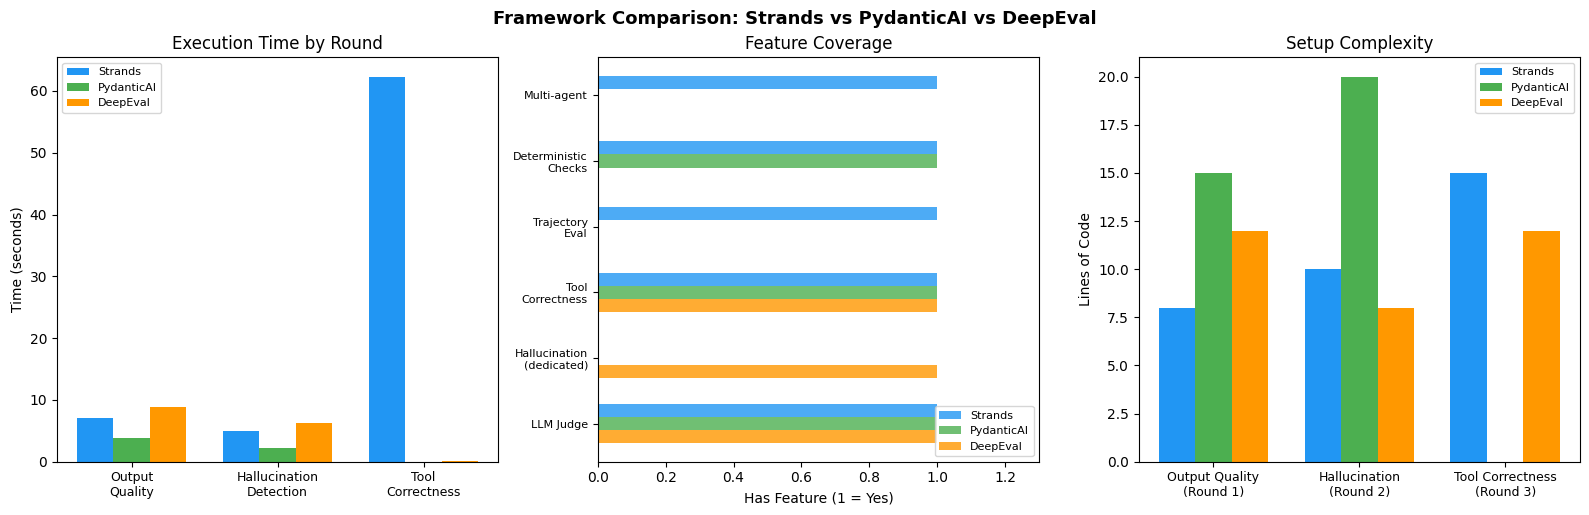

In [20]:
"""Visual comparison charts."""

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = 'white'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Colors for each framework
colors = {'Strands': '#2196F3', 'PydanticAI': '#4CAF50', 'DeepEval': '#FF9800'}

# --- Chart 1: Execution Time by Round ---
ax = axes[0]
rounds = ['Output\nQuality', 'Hallucination\nDetection', 'Tool\nCorrectness']
strands_times = [strands_quality_time, strands_hallucination_time, strands_traj_time]
pydantic_times = [pydantic_quality_time, pydantic_hallucination_time, 0]
deepeval_times = [deepeval_quality_time, deepeval_hallucination_time, deepeval_tool_time]

x = range(len(rounds))
width = 0.25
ax.bar([i - width for i in x], strands_times, width, label='Strands', color=colors['Strands'])
ax.bar(x, pydantic_times, width, label='PydanticAI', color=colors['PydanticAI'])
ax.bar([i + width for i in x], deepeval_times, width, label='DeepEval', color=colors['DeepEval'])
ax.set_ylabel('Time (seconds)')
ax.set_title('Execution Time by Round')
ax.set_xticks(x)
ax.set_xticklabels(rounds, fontsize=9)
ax.legend(fontsize=8)

# --- Chart 2: Feature Coverage (what each framework supports) ---
ax = axes[1]
features = ['LLM Judge', 'Hallucination\n(dedicated)', 'Tool\nCorrectness', 'Trajectory\nEval', 'Deterministic\nChecks', 'Multi-agent']
strands_feat = [1, 0, 1, 1, 1, 1]   # 1 = has it, 0 = doesn't
pydantic_feat = [1, 0, 1, 0, 1, 0]
deepeval_feat = [1, 1, 1, 0, 0, 0]

x = range(len(features))
ax.barh([f + 0.2 for f in x], strands_feat, 0.2, label='Strands', color=colors['Strands'], alpha=0.8)
ax.barh(x, pydantic_feat, 0.2, label='PydanticAI', color=colors['PydanticAI'], alpha=0.8)
ax.barh([f - 0.2 for f in x], deepeval_feat, 0.2, label='DeepEval', color=colors['DeepEval'], alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(features, fontsize=8)
ax.set_xlabel('Has Feature (1 = Yes)')
ax.set_title('Feature Coverage')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(0, 1.3)

# --- Chart 3: Setup Complexity (lines of code per round) ---
ax = axes[2]
categories = ['Output Quality\n(Round 1)', 'Hallucination\n(Round 2)', 'Tool Correctness\n(Round 3)']
strands_loc = [8, 10, 15]
pydantic_loc = [15, 20, 0]  # 0 = not applicable
deepeval_loc = [12, 8, 12]

x = range(len(categories))
ax.bar([i - width for i in x], strands_loc, width, label='Strands', color=colors['Strands'])
ax.bar(x, pydantic_loc, width, label='PydanticAI', color=colors['PydanticAI'])
ax.bar([i + width for i in x], deepeval_loc, width, label='DeepEval', color=colors['DeepEval'])
ax.set_ylabel('Lines of Code')
ax.set_title('Setup Complexity')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=9)
ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Framework Comparison: Strands vs PydanticAI vs DeepEval', fontsize=13, fontweight='bold', y=1.02)
plt.show()

## Conclusion

### When to Use Each

| Use Case | Best Choice | Why |
|----------|-------------|-----|
| You use **Strands Agents** for your agent | **Strands evals** | Same ecosystem, hooks, built-in metrics |
| You want **type-safe** evaluation pipelines | **PydanticAI** | Strongest typing, YAML datasets, report diffing |
| You need the **most metrics out-of-the-box** | **DeepEval** | 30+ metrics, hallucination/faithfulness specialized |
| You need **trajectory + tool** evaluation | **Strands** | Built-in extractors, TrajectoryEvaluator, deterministic checks |
| You need **multi-agent** evaluation | **Strands** | InteractionsEvaluator, Swarm/Graph orchestration |
| You want **framework-agnostic** evaluation | **DeepEval** | Works with any agent framework, no coupling |
| You want **report comparison** across runs | **PydanticAI** | Baseline diffing built into `.print()` |

### The Bottom Line

There is no single "best" framework. The evaluation concepts (LLM-as-judge, trajectory scoring, hallucination detection) are framework-independent. Choose based on your stack:

- **Already using Strands Agents** → Strands evals (tightest integration)
- **Want type safety and structured pipelines** → PydanticAI
- **Want maximum built-in metrics** → DeepEval

All three are production-quality. The best evaluation framework is the one you actually use.